In [1]:
SDS_TOP = '/Volumes/classdata/KSC/20260403_service/20_archive/SDS'
from flovopy.enhanced.sdsclient import EnhancedSDSClient
from obspy import UTCDateTime
starttime = UTCDateTime(2026,4,1,22,0,0)
endtime = UTCDateTime(2026,4,1,23,0,0)
net='DG'
client = EnhancedSDSClient(SDS_TOP)
st = client.get_waveforms(net, '*', '*', '*', starttime, endtime)
print(st)

7 Trace(s) in Stream:
DG.B07.1L.CHZ | 2026-04-01T22:00:00.000000Z - 2026-04-01T23:00:00.000000Z | 500.0 Hz, 1800001 samples
DG.B12.1L.CHE | 2026-04-01T22:30:00.534000Z - 2026-04-01T22:45:01.776000Z | 500.0 Hz, 450622 samples
DG.B12.1L.CHN | 2026-04-01T22:30:05.202000Z - 2026-04-01T22:45:04.946000Z | 500.0 Hz, 449873 samples
DG.B12.1L.CHZ | 2026-04-01T22:30:04.532000Z - 2026-04-01T22:44:57.758000Z | 500.0 Hz, 446614 samples
DG.B23.01.CLE | 2026-04-01T22:00:00.000000Z - 2026-04-01T23:00:00.000000Z | 500.0 Hz, 1800001 samples
DG.B23.01.CLN | 2026-04-01T22:00:00.000000Z - 2026-04-01T23:00:00.000000Z | 500.0 Hz, 1800001 samples
DG.B23.01.CLZ | 2026-04-01T22:00:00.000000Z - 2026-04-01T23:00:00.000000Z | 500.0 Hz, 1800001 samples


In [42]:
st.write('DG_network_artemis2.mseed')


/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/io/mseed/core.py:1087: UserWarning: File will be written with more than one different record lengths.
This might have a negative influence on the compatibility with other programs.
  warnings.warn(msg % 'record lengths')
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/io/mseed/core.py:1089: UserWarning: File will be written with more than one different byteorders.
This might have a negative influence on the compatibility with other programs.
  warnings.warn(msg % 'byteorders')


/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


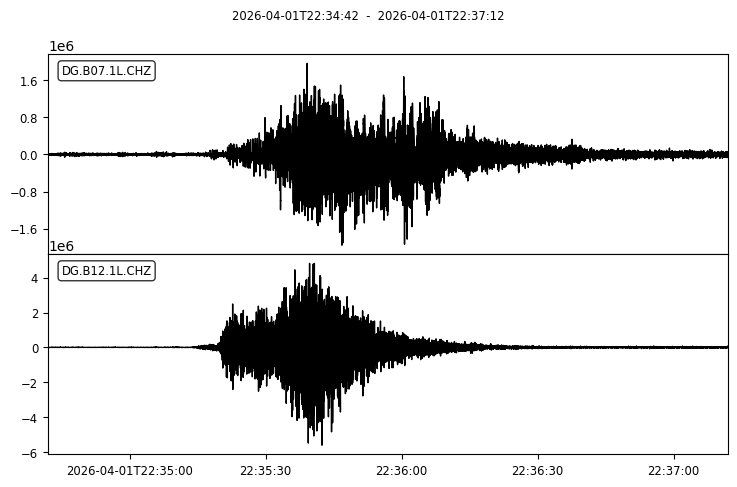

In [10]:
st2=st.copy().select(component='Z')
st2.remove(st2[-1])
st2.detrend('linear').filter('highpass', freq=0.5)
st2.trim(starttime=eventtime-30,endtime=eventtime+120)
st2.plot(equal_scale=False);

In [44]:
st2.write('DG_network_artemis2.mseed')

/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/io/mseed/core.py:1034: UserWarning: The encoding specified in trace.stats.mseed.encoding does not match the dtype of the data.
A suitable encoding will be chosen.
  warnings.warn(msg, UserWarning)


(<Figure size 576x756 with 8 Axes>,
 array([<Axes: >, <Axes: ylabel='     B07.CHZ'>, <Axes: >,
        <Axes: xlabel='Time [s]', ylabel='     B12.CHZ'>], dtype=object))

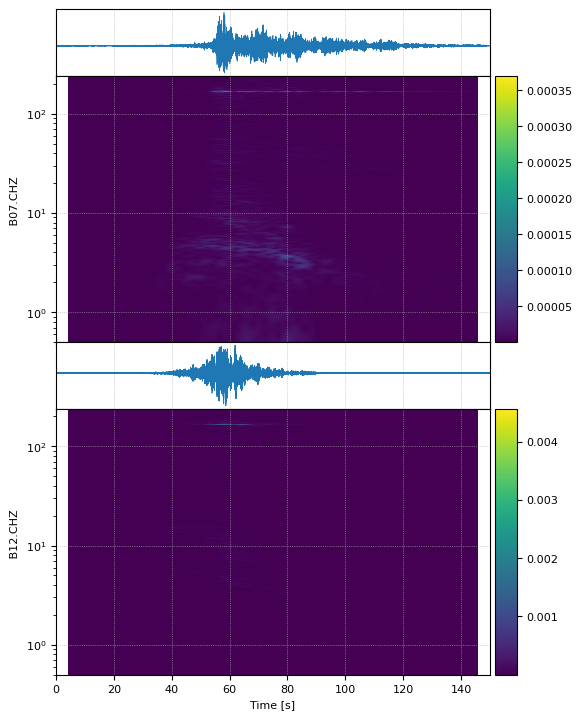

In [36]:
#st2.spectrogram()
from flovopy.processing.spectrograms import icewebSpectrogram
spobj = icewebSpectrogram(st4, secsPerFFT=10.24)
spobj.plot(fmax=240, log=True)

(<Figure size 576x756 with 5 Axes>,
 array([<Axes: >, <Axes: ylabel='     B07.CHZ'>, <Axes: >,
        <Axes: xlabel='Time [s]', ylabel='     B12.CHZ'>], dtype=object))

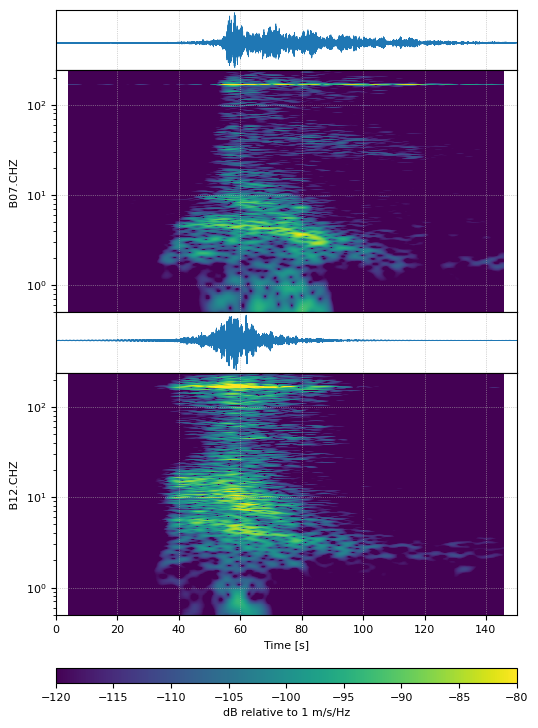

In [41]:
spobj.plot(fmax=240, log=True, dbscale=True, equal_scale=True, clim=[1e-6, 1e-4])

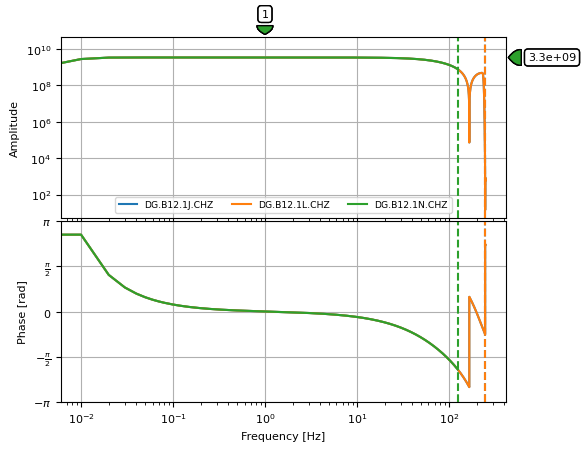

ValueError: No matching response information found.

In [25]:
from obspy import read_inventory
inv0 = read_inventory('/Volumes/classdata/KSC/20260310_service/Guralp_day1/Sensor0.xml')
inv1 = read_inventory('/Volumes/classdata/KSC/20260310_service/Guralp_day1/Sensor1.xml')
inv1.select(channel='CHZ').plot_response(min_freq=0.01)
st3=st2.copy()
st3.remove_response(inv0)
st3.plot()

DG.B12.1L.CHZ | 2026-04-01T22:34:42.000000Z - 2026-04-01T22:37:12.000000Z | 500.0 Hz, 75001 samples
DG.B07.1L.CHZ | 2026-04-01T22:34:42.000000Z - 2026-04-01T22:37:12.000000Z | 500.0 Hz, 75001 samples
2 Trace(s) in Stream:
DG.B07.1L.CHZ | 2026-04-01T22:34:42.000000Z - 2026-04-01T22:37:12.000000Z | 500.0 Hz, 75001 samples
DG.B12.1L.CHZ | 2026-04-01T22:34:42.000000Z - 2026-04-01T22:37:12.000000Z | 500.0 Hz, 75001 samples


/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/util.py:266: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small')
/opt/anaconda3/envs/flovopy_env/lib/python3.12/site-packages/obspy/imaging/waveform.py:822: UserWarning: AutoDateLocator was unable to pick an appropriate interval for this date range. It may be necessary to add an interval value to the AutoDateLocator's intervald dictionary. Defaulting to 30.
  plt.setp(ax.get_xticklabels(), fontsize='small',


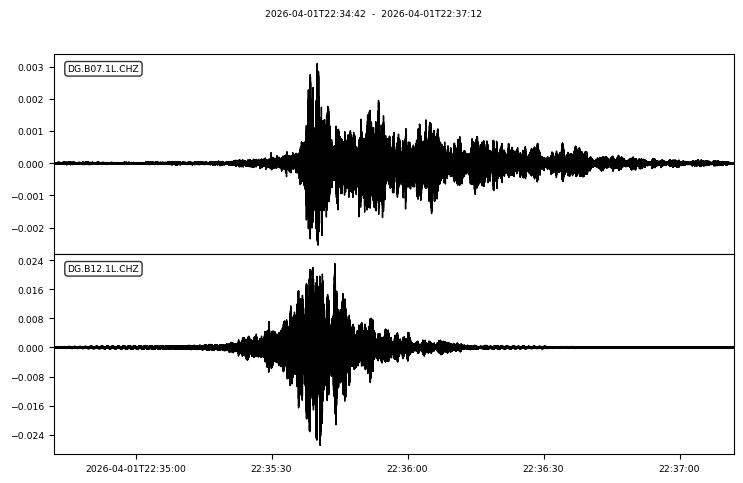

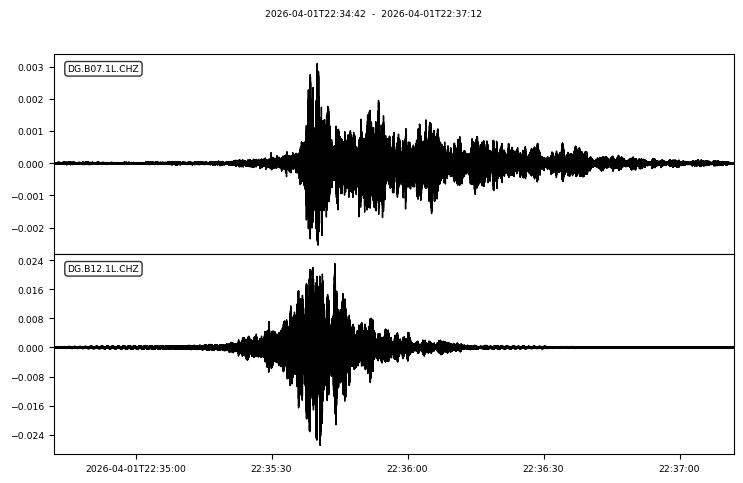

In [35]:
from obspy import Stream
st3=st2.copy()
b12=st3.select(station='B12')[0].copy().remove_response(inv1)
print(b12)
b07 = st3.select(station='B07')[0].copy()
#print(b07)
b07.stats.station='B12'
b07.remove_response(inv1)
b07.stats.station='B07'
print(b07)
st4 = Stream(traces=[b07, b12])
print(st4)
st4.plot(equal_scale=False)

